Instalasi

In [90]:
import sys
print(sys.executable)

c:\Users\MSI CYBORG\AppData\Local\Programs\Python\Python313\python.exe


Import Library

In [79]:
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np

Inisialisasi Path Dataset

In [80]:
root_path = 'dataset/' 

if not os.path.exists(root_path):
    print(f"ERROR: Folder tidak ditemukan di {root_path}")
    print("Pastikan folder 'dataset' berada di folder yang sama dengan file .ipynb ini.")

Visualization (Memuat Dataset)

Memuat dataset wajah...


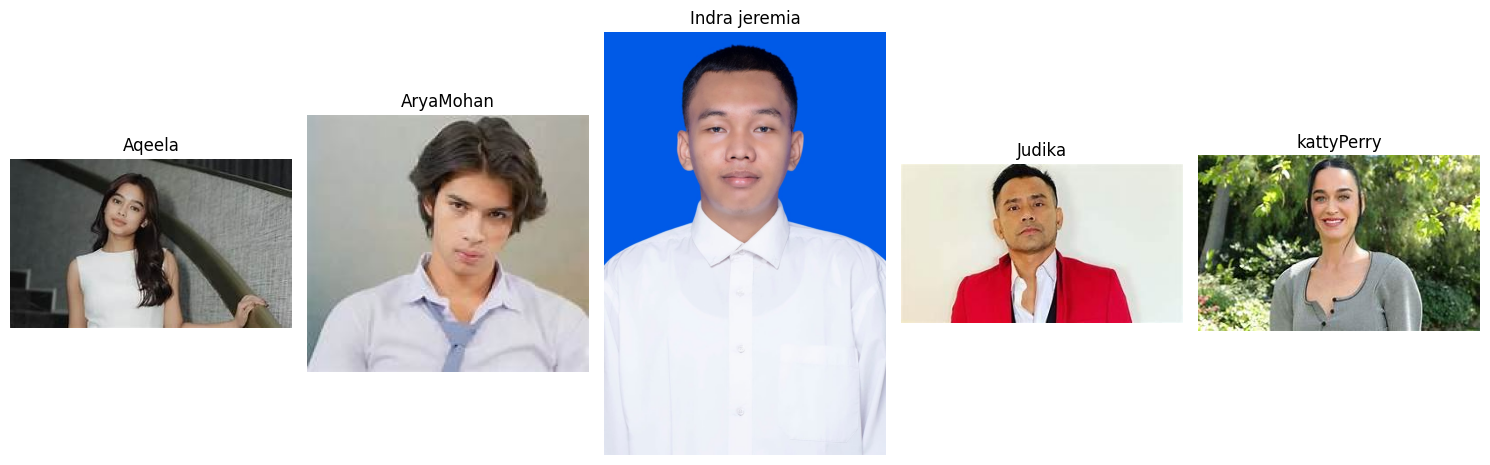

Dataset berhasil dimuat: 7 orang terdeteksi.


In [81]:
# Ambil daftar nama folder orang (Aqeela, Indra jeremia, dll)
person_names = [f for f in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, f))]

images_data = []
labels = []

print("Memuat dataset wajah...")
plt.figure(figsize=(15, 5))

for i, name in enumerate(person_names):
    person_folder = os.path.join(root_path, name)
    face_images = [img for img in os.listdir(person_folder) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if len(face_images) > 0:
        img_path = os.path.join(person_folder, face_images[0])
        image = cv2.imread(img_path)

        if image is not None:
            images_data.append(image)
            labels.append(name)

            # Tampilkan 5 gambar pertama
            if i < 5:
                plt.subplot(1, 5, i + 1)
                plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
                plt.title(name)
                plt.axis('off')

plt.tight_layout()
plt.show()
print(f"Dataset berhasil dimuat: {len(labels)} orang terdeteksi.")

Grayscale

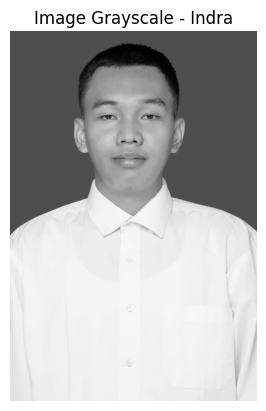

In [82]:
# --- Grayscale ---

# Kita ambil gambar index ke-2 sebagai contoh (asumsi foto Indra)
# images_data didapat dari cell sebelumnya
img_contoh = images_data[2]

# Mengubah warna dari BGR (OpenCV default) ke Grayscale
img_gray = cv2.cvtColor(img_contoh, cv2.COLOR_BGR2GRAY)

# Menampilkan hasil
plt.imshow(img_gray, cmap='gray')
plt.title("Image Grayscale - Indra")
plt.axis('off')
plt.show()

Blurring (Bilateral Filter)

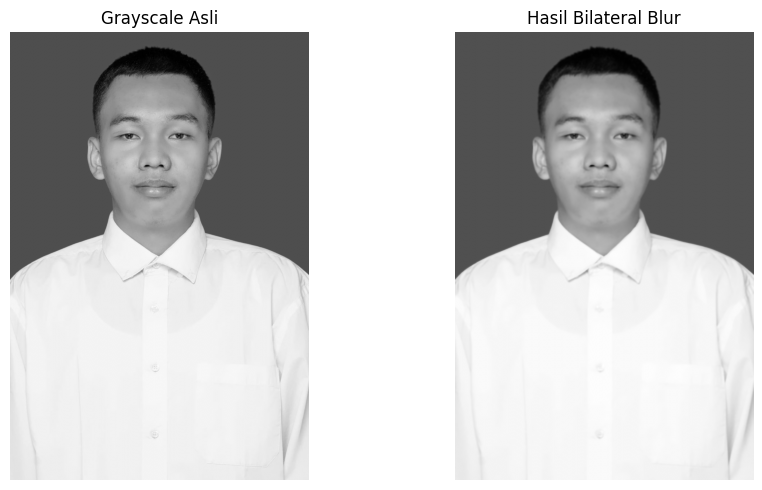

In [83]:
# --- Blurring ---

# Menerapkan Bilateral Filter untuk menghaluskan noise tanpa merusak tepi
blur_bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)

# Menampilkan perbandingan
plt.figure(figsize=(10, 5))

# Subplot 1: Gambar Grayscale Asli
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Asli")
plt.axis('off')

# Subplot 2: Gambar Hasil Blur
plt.subplot(1, 2, 2)
plt.imshow(blur_bilateral, cmap='gray')
plt.title("Hasil Bilateral Blur")
plt.axis('off')

plt.tight_layout()
plt.show()

Face Location & Cropping

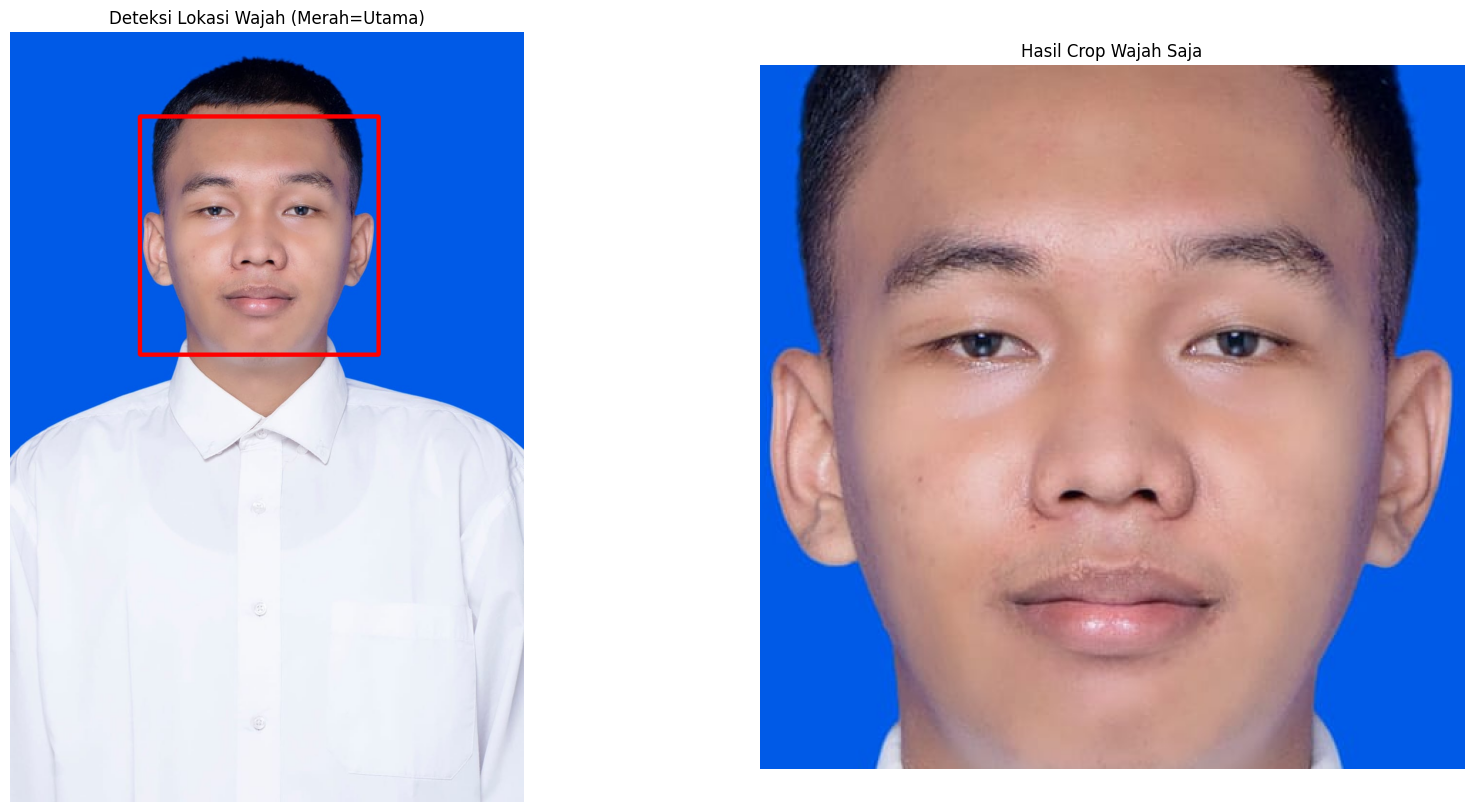

In [84]:
def crop_face(img_input):
    # 1. Load pendeteksi wajah bawaan OpenCV
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # 2. Pastikan gambar dalam grayscale untuk deteksi
    gray_temp = cv2.cvtColor(img_input, cv2.COLOR_BGR2GRAY)

    # 3. Cari Wajah 
    faces = face_cascade.detectMultiScale(gray_temp, 1.1, 5)

    results = []

    for (x, y, w, h) in faces:
        # Filter: Abaikan jika area deteksi terlalu kecil (noise)
        if (w * h) < 1000:
            continue

        # Potong bagian wajah
        candidate = img_input[y:y+h, x:x+w]
        results.append(((x, y, w, h), candidate))

    # Ambil wajah pertama sebagai kandidat terbaik
    if results:
        best_loc, best_img = results[0]
        return best_img, results

    return None, []

# Eksekusi fungsi crop wajah menggunakan foto Indra (index 2)
face_img, all_face_candidates = crop_face(images_data[2])

# Visualisasi 
fig = plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
img_detected = cv2.cvtColor(images_data[2], cv2.COLOR_BGR2RGB).copy()
if all_face_candidates:
    for (x, y, w, h), _ in all_face_candidates:
        # Kotak Hijau untuk semua kandidat wajah
        cv2.rectangle(img_detected, (x, y), (x+w, y+h), (0, 255, 0), 5)

    # Kotak Merah untuk wajah utama
    (x, y, w, h), _ = all_face_candidates[0]
    cv2.rectangle(img_detected, (x, y), (x+w, y+h), (255, 0, 0), 8)

plt.imshow(img_detected)
plt.title('Deteksi Lokasi Wajah (Merah=Utama)')
plt.axis('off')

plt.subplot(1, 2, 2)
if face_img is not None:
    face_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
    plt.imshow(face_rgb)
    plt.title('Hasil Crop Wajah Saja')
else:
    plt.imshow(np.zeros((100, 100, 3), dtype=np.uint8))
    plt.title('Wajah Tidak Ditemukan')
plt.axis('off')

plt.show()

Morphology & Thresholding

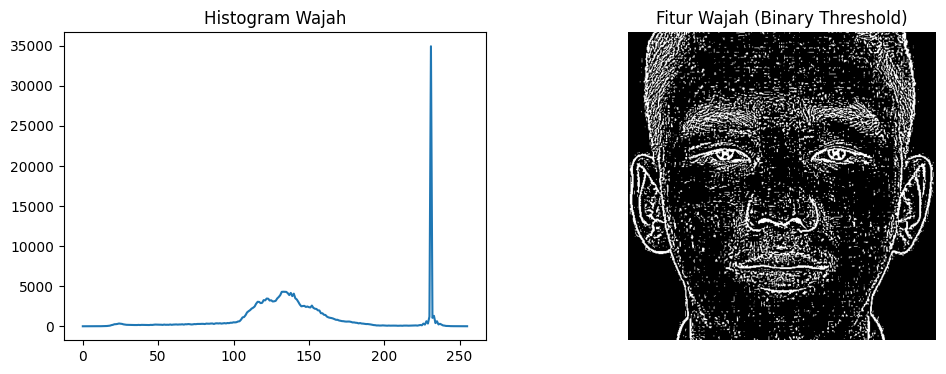

In [85]:
# 1. Histogram 
calc_hist = cv2.calcHist([face_img], [0], None, [256], [0, 256])

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(calc_hist)
plt.title("Histogram Wajah")

# 2. Thresholding untuk melihat fitur wajah secara biner
# Kita gunakan face_img yang sudah grayscale dari tahap sebelumnya
face_gray = cv2.cvtColor(face_img, cv2.COLOR_BGR2GRAY)
thresh_face = cv2.adaptiveThreshold(face_gray, 255,
                                     cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 11, 2)

plt.subplot(1, 2, 2)
plt.imshow(thresh_face, cmap='gray')
plt.title("Fitur Wajah (Binary Threshold)")
plt.axis('off')
plt.show()

Resize with Padding (Standardization)

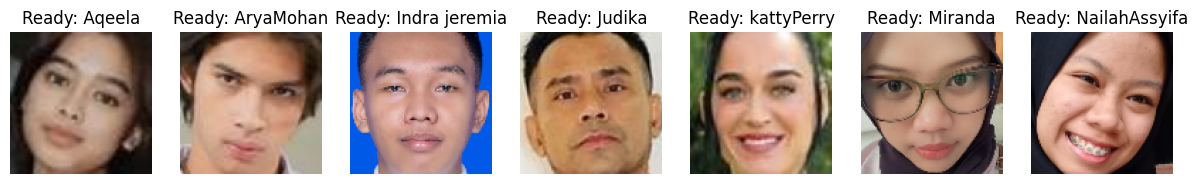

In [86]:
def resize_face_standard(img, target_size=100):
    h, w = img.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)

    resized = cv2.resize(img, (new_w, new_h))

    # Buat canvas hitam
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    # Hitung posisi tengah (Center)
    x_offset = (target_size - new_w) // 2
    y_offset = (target_size - new_h) // 2

    # Tempel wajah ke tengah canvas
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
    return canvas

# Mari kita standarisasi semua wajah yang ada di dataset
plt.figure(figsize=(15, 3))
standardized_faces = []

for i, img in enumerate(images_data):
    # Deteksi dan crop dulu tiap wajah
    cropped, _ = crop_face(img)
    if cropped is not None:
        final_face = resize_face_standard(cropped, target_size=100)
        standardized_faces.append(final_face)

        # Tampilkan hasil akhir yang sudah seragam
        plt.subplot(1, len(images_data), i + 1)
        plt.imshow(cv2.cvtColor(final_face, cv2.COLOR_BGR2RGB))
        plt.title(f"Ready: {labels[i]}")
        plt.axis('off')

plt.show()

Face Recognition (Matching)

untuk menjalan pipeline Face Recognition (Matching) diperlukan python versi 3.10 atau langsung diakses pada terminal di file app.py dengan cara streamlit run app.py

In [ ]:
import face_recognition

# 1. Membuat Database Encoding (Ciri Khas Wajah)
known_face_encodings = []
known_face_names = []

print("Sedang memproses database wajah...")

for i, img in enumerate(images_data):
    # Ubah ke RGB (Syarat library face_recognition)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Ambil lokasi wajah dan encoding-nya
    boxes = face_recognition.face_locations(rgb_img)
    encodings = face_recognition.face_encodings(rgb_img, boxes)

    if len(encodings) > 0:
        known_face_encodings.append(encodings[0])
        known_face_names.append(labels[i])

print(f"Selesai! {len(known_face_names)} wajah telah didaftarkan.")

def recognize_face(test_img_path):
    test_img = cv2.imread(test_img_path)
    rgb_test = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)

    # Cari wajah di foto tes
    face_locations = face_recognition.face_locations(rgb_test)
    face_encodings = face_recognition.face_encodings(rgb_test, face_locations)

    for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
        # Bandingkan dengan database
        matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
        name = "Unknown" # Default jika tidak kenal

        # Cari jarak kemiripan terkecil
        face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
        best_match_index = np.argmin(face_distances)

        if matches[best_match_index]:
            name = known_face_names[best_match_index]

        cv2.rectangle(test_img, (left, top), (right, bottom), (0, 255, 0), 5)
        cv2.putText(test_img, name, (left, top - 10), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 4)

    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Tahap Testing (Pembuktian)

In [ ]:
# Masukkan alamat foto yang ingin kamu tes di sini
# Contoh: kita mau tes foto Indra yang lain
path_foto_tes = 'dataset/Indra_jeremia/Indra_jeremia.jpeg'

# Panggil fungsinya untuk memproses foto tersebut
recognize_face(path_foto_tes)